# Dự Đoán Điểm Cuối Kỳ

**Bài toán:** Xây dựng hàm dự đoán điểm cuối kỳ dựa trên điểm giữa kỳ  
**Dataset:** `TRAIN2.xlsx` (515 mẫu, 2 cột: `midterm`, `final`)  
**Phương pháp:** Linear Regression với Gradient Descent (PyTorch autograd)  
**Learning rate:** 0.01 | **Epochs:** 1000  

## 1. Import thư viện & Mount Google Drive

In [3]:
import numpy as np
import pandas as pd
import torch


## 2. Nạp dữ liệu từ TRAIN2.xlsx

In [4]:
path = "./TRAIN2.xlsx"
df = pd.read_excel(path)

print(f"Số mẫu dữ liệu : {len(df)}")
print(f"Cột dữ liệu    : {list(df.columns)}")
print()
df.head()

Số mẫu dữ liệu : 515
Cột dữ liệu    : ['final', 'midterm']



,final,midterm
0,2.56,0.70
1,2.78,0.97
2,6.35,5.43
3,5.99,4.99
4,7.67,7.09


## 3. Chuẩn bị Tensor

In [5]:
n = len(df)

X = torch.tensor(df["midterm"].values, dtype=torch.float32).reshape(n, 1)
Y = torch.tensor(df["final"].values,   dtype=torch.float32).reshape(n, 1)

# Khởi tạo tham số W và b = 0
learning_rate = 0.01
W = torch.tensor([[0]], dtype=torch.float32, requires_grad=True)
b = torch.tensor([[0]], dtype=torch.float32, requires_grad=True)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")
print(f"W khởi tạo: {W.item()}, b khởi tạo: {b.item()}")

X shape: torch.Size([515, 1])
Y shape: torch.Size([515, 1])
W khởi tạo: 0.0, b khởi tạo: 0.0


## 4. Huấn luyện — Gradient Descent (1000 epochs)

In [6]:
epochs = 1000
loss_history = []

for epoch in range(epochs):
    # Forward pass: Y_pred = X * W + b
    Y_pred = torch.matmul(X, W) + b

    # Tính MSE loss
    Z    = Y - Y_pred
    Loss = Z ** 2
    MSE  = Loss.mean()

    # Backward pass
    MSE.backward()

    # Cập nhật tham số (không tính gradient)
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    # Xóa gradient cũ
    W.grad.zero_()
    b.grad.zero_()

    loss_history.append(MSE.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1:>4}/{epochs}]  MSE = {MSE.item():.6f}")

print()
print(W, b)

Epoch [ 100/1000]  MSE = 0.321068
Epoch [ 200/1000]  MSE = 0.119375
Epoch [ 300/1000]  MSE = 0.044387
Epoch [ 400/1000]  MSE = 0.016508
Epoch [ 500/1000]  MSE = 0.006143
Epoch [ 600/1000]  MSE = 0.002289
Epoch [ 700/1000]  MSE = 0.000856
Epoch [ 800/1000]  MSE = 0.000323
Epoch [ 900/1000]  MSE = 0.000125
Epoch [1000/1000]  MSE = 0.000052

tensor([[0.8020]], requires_grad=True) tensor([[1.9888]], requires_grad=True)


## 5. Kết quả

In [7]:
print("=" * 45)
print("KẾT QUẢ SAU TRAINING:")
print(f"  W (hệ số góc)   = {W.item():.4f}")
print(f"  b (hệ số tự do) = {b.item():.4f}")
print("=" * 45)
print(f"\nPhương trình hồi quy:")
print(f"  final = {W.item():.4f} × midterm + ({b.item():.4f})")

print("\nVí dụ dự đoán:")
for score in [3.0, 5.0, 7.0, 9.0]:
    pred = W.item() * score + b.item()
    print(f"  Giữa kỳ = {score:.1f}  →  Cuối kỳ ≈ {pred:.2f}")

KẾT QUẢ SAU TRAINING:
  W (hệ số góc)   = 0.8020
  b (hệ số tự do) = 1.9888

Phương trình hồi quy:
  final = 0.8020 × midterm + (1.9888)

Ví dụ dự đoán:
  Giữa kỳ = 3.0  →  Cuối kỳ ≈ 4.39
  Giữa kỳ = 5.0  →  Cuối kỳ ≈ 6.00
  Giữa kỳ = 7.0  →  Cuối kỳ ≈ 7.60
  Giữa kỳ = 9.0  →  Cuối kỳ ≈ 9.21


## 6. Vẽ đồ thị Loss & Đường hồi quy

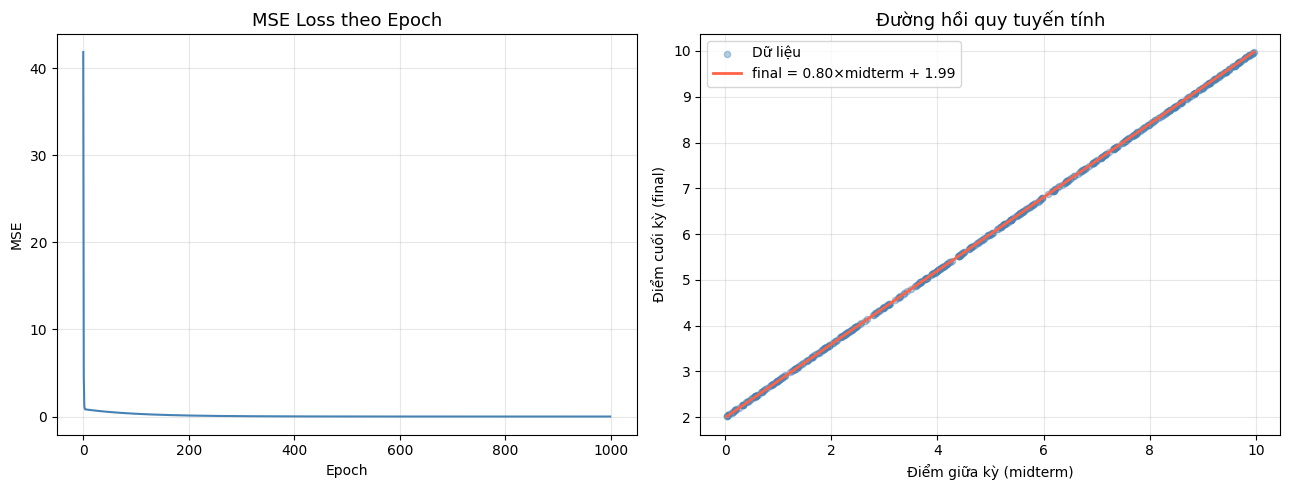

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Đồ thị 1: Loss curve ---
axes[0].plot(loss_history, color='steelblue', linewidth=1.5)
axes[0].set_title('MSE Loss theo Epoch', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].grid(True, alpha=0.3)

# --- Đồ thị 2: Dữ liệu & đường hồi quy ---
x_vals = df["midterm"].values
y_vals = df["final"].values
y_line = W.item() * x_vals + b.item()

axes[1].scatter(x_vals, y_vals, alpha=0.4, s=20, color='steelblue', label='Dữ liệu')
axes[1].plot(sorted(x_vals), sorted(y_line), color='tomato', linewidth=2,
             label=f'final = {W.item():.2f}×midterm + {b.item():.2f}')
axes[1].set_title('Đường hồi quy tuyến tính', fontsize=13)
axes[1].set_xlabel('Điểm giữa kỳ (midterm)')
axes[1].set_ylabel('Điểm cuối kỳ (final)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()